In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv('car_sales_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [4]:
df.isna().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [5]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


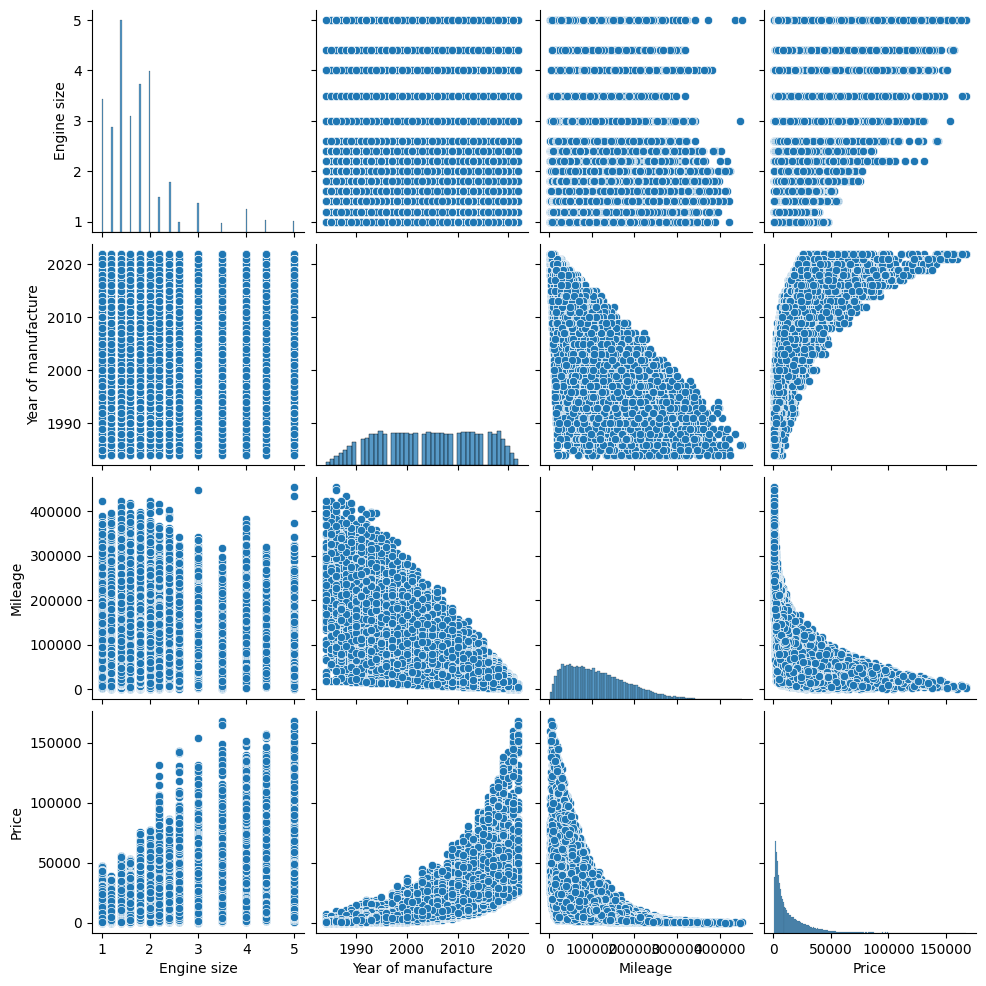

In [6]:
sns.pairplot(df[['Engine size', 'Year of manufacture', 'Mileage', 'Price']])

<Axes: xlabel='Year of manufacture', ylabel='Price'>

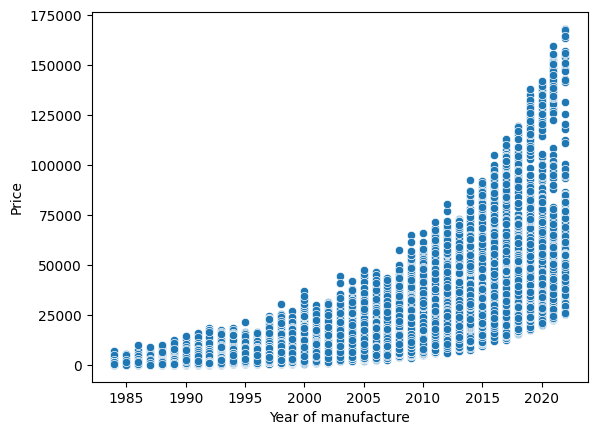

In [7]:
sns.scatterplot(x='Year of manufacture', y='Price', data=df)

In [8]:
X = df['Year of manufacture'].values.reshape(-1, 1)
y = df['Price']

In [9]:
from sklearn.model_selection import train_test_split   
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [11]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# 1. Weight (Slope)
print("Weight (Slope):", model.coef_)

# 2. Bias (Intercept)
print("Bias (Intercept):", model.intercept_)


Weight (Slope): [1217.32908476]
Bias (Intercept): -2425916.4569782093


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on the test set
y_pred = model.predict(x_test)

# 3. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# 4. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

# 5.root mean absolute error
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 128259137.74809693
Mean Absolute Error (MAE): 7022.911641969813
Root Mean Squared Error (RMSE): 11325.1550871543


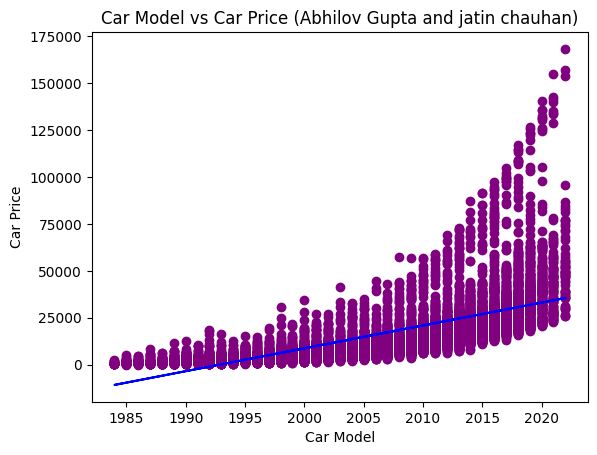

In [14]:
#visualising the result
plt.scatter(x_test,y_test, color= 'purple')
plt.plot(x_test, model.predict(x_test), color='blue')
plt.title('Car Model vs Car Price (Abhilov Gupta and jatin chauhan)')
plt.xlabel('Car Model')
plt.ylabel('Car Price')
plt.show()

## Linear regression is not a good choice for this model so we are going to try the logistic regression

In [15]:
from sklearn.preprocessing import PolynomialFeatures


In [16]:
poly = PolynomialFeatures(degree=4)

In [17]:
X_poly = poly.fit_transform(X)

In [18]:
model.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


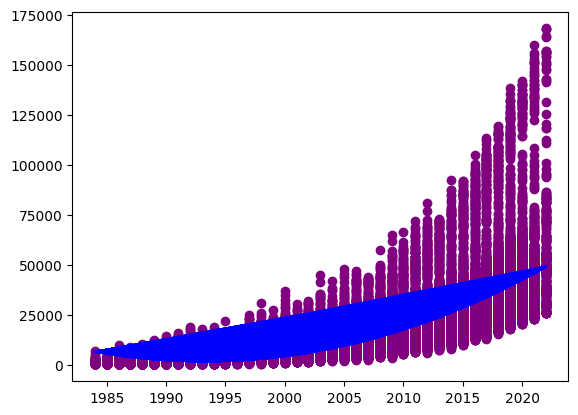

In [19]:
y_pred = model.predict(X_poly)
plt.scatter(X, y, color='purple')
plt.plot(X, y_pred, color='blue')
plt.show()

In [20]:
model = LinearRegression()
X_poly = poly.fit_transform(x_train)
model.fit(X_poly, y_train)

y_pred = model.predict(poly.transform(x_test))

In [21]:
y_pred

array([23933.6989677 , 21728.56532405,  6042.81512679, ...,
        2977.35539339,  2124.98366891,  2494.66130513], shape=(10000,))

In [22]:
from sklearn.metrics import mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MSE: 103258374.84404965
RMSE: 10161.612807229452


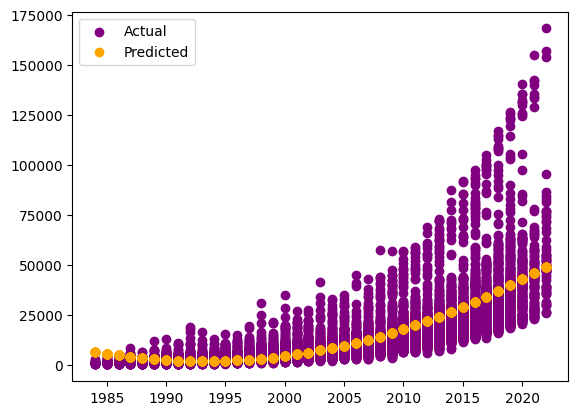

In [23]:
plt.scatter(x_test, y_test, color="purple", label="Actual")
plt.scatter(x_test, y_pred, color="orange", label="Predicted")
plt.legend()
plt.show()